In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
# load the data, all selected 54 features and Imax

# load the features
features_df = pd.read_csv('data/features_df_v1.csv')
mX = features_df.loc[:, "f1_mass_PC1":].astype(float).values # bring all standardized features to the float
print(f'The shape of the feature matrix is {mX.shape}')

# load the data
data_df = pd.read_csv('data/waka_dragon_merged.csv')
vY = data_df['Imax'].astype(float).values
print(f'The shape of the target vector is {vY.shape}')

The shape of the feature matrix is (312, 54)
The shape of the target vector is (312,)


In [ ]:
# ML imports
from sklearn.linear_model import LinearRegression, lasso_path
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_predict, train_test_split
from sklearn.linear_model import Lasso, Ridge
from sklearn.pipeline import Pipeline


In [ ]:
# as a first stet i want to implement a linear regression model strightforward on all set
oLinReg = LinearRegression().fit(mX, vY)
vY_pred = oLinReg.predict(mX)

# calculate the R2 score
r2 = r2_score(vY, vY_pred)
mae = mean_absolute_error(vY, vY_pred)
print(f'The R2 score is {r2:.2f}')
print(f'The MAE is {mae:.2f}')


The R2 score is 0.63
The MAE is 7.32


In [12]:
# as next step i want to do cross-validation
kf = KFold(n_splits=len(vY), shuffle=True, random_state=42) # split for all samples
vY_pred = cross_val_predict(oLinReg, mX, vY, cv=kf)

# calculate the R2 score
r2 = r2_score(vY, vY_pred)
print(f'The R2 score is {r2:.2f}')
# calculate the MAE
mae = mean_absolute_error(vY, vY_pred)
print(f'The MAE is {mae:.2f}')

The R2 score is 0.22
The MAE is 9.45


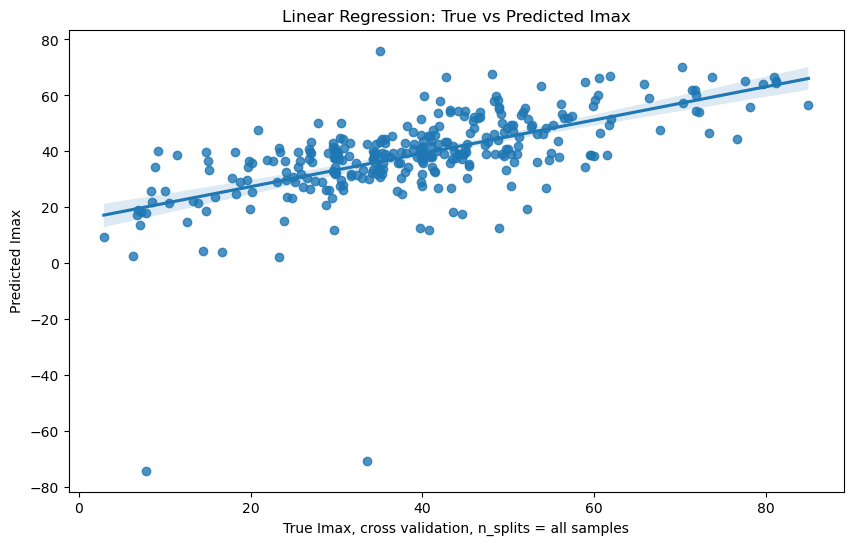

In [15]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.regplot(x=vY, y=vY_pred, ax=ax)
ax.set_xlabel('True Imax, cross validation, n_splits = all samples')
ax.set_ylabel('Predicted Imax')
ax.set_title('Linear Regression: True vs Predicted Imax')
plt.show()


In [20]:
# as next step i want to try Lasso regression

# define the range of alpha values
lAlpha = np.linspace(0.0001, 5, 100)
kf = KFold(n_splits=len(vY), shuffle=True, random_state=42) # split for all samples
# i want to create an empty dataframe with the columns alpha, R2, MAE, RMSE, MSE
dfLasso = pd.DataFrame(columns=['alpha', 'R2', 'MAE', 'RMSE', 'MSE'], dtype=float)
dfLasso['alpha'] = lAlpha
dfLasso['R2'] = [0.0] * len(lAlpha)
dfLasso['MAE'] = [0.0] * len(lAlpha)
dfLasso['RMSE'] = [0.0] * len(lAlpha)
dfLasso['MSE'] = [0.0] * len(lAlpha)

for i, alpha in enumerate(lAlpha):
    print(f"Training Lasso with alpha = {alpha} model {i+1} of {len(lAlpha)}")
    oLasso = Lasso(alpha=alpha)
    vY_pred = cross_val_predict(oLasso, mX, vY, cv=kf)
    dfLasso.loc[i, 'R2'] = r2_score(vY, vY_pred)
    dfLasso.loc[i, 'MAE'] = mean_absolute_error(vY, vY_pred)
    dfLasso.loc[i, 'RMSE'] = np.sqrt(mean_squared_error(vY, vY_pred))
    dfLasso.loc[i, 'MSE'] = mean_squared_error(vY, vY_pred)



Training Lasso with alpha = 0.0001 model 1 of 100


c:\Users\KirilKiriyevsky\PythonMamba\envs\AIProgram\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.416e+04, tolerance: 7.587e+00
  model = cd_fast.enet_coordinate_descent(
c:\Users\KirilKiriyevsky\PythonMamba\envs\AIProgram\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.419e+04, tolerance: 7.532e+00
  model = cd_fast.enet_coordinate_descent(
c:\Users\KirilKiriyevsky\PythonMamba\envs\AIProgram\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the

Training Lasso with alpha = 0.05060404040404041 model 2 of 100


c:\Users\KirilKiriyevsky\PythonMamba\envs\AIProgram\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.417e+01, tolerance: 7.597e+00
  model = cd_fast.enet_coordinate_descent(
c:\Users\KirilKiriyevsky\PythonMamba\envs\AIProgram\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.399e+00, tolerance: 7.593e+00
  model = cd_fast.enet_coordinate_descent(
c:\Users\KirilKiriyevsky\PythonMamba\envs\AIProgram\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the

Training Lasso with alpha = 0.10110808080808081 model 3 of 100


...

Training Lasso with alpha = 0.1516121212121212 model 4 of 100


c:\Users\KirilKiriyevsky\PythonMamba\envs\AIProgram\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.826e+01, tolerance: 7.599e+00
  model = cd_fast.enet_coordinate_descent(
c:\Users\KirilKiriyevsky\PythonMamba\envs\AIProgram\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.780e+01, tolerance: 7.596e+00
  model = cd_fast.enet_coordinate_descent(
c:\Users\KirilKiriyevsky\PythonMamba\envs\AIProgram\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the

Training Lasso with alpha = 0.2021161616161616 model 5 of 100


c:\Users\KirilKiriyevsky\PythonMamba\envs\AIProgram\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.562e+01, tolerance: 7.599e+00
  model = cd_fast.enet_coordinate_descent(
c:\Users\KirilKiriyevsky\PythonMamba\envs\AIProgram\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.779e+01, tolerance: 7.601e+00
  model = cd_fast.enet_coordinate_descent(
c:\Users\KirilKiriyevsky\PythonMamba\envs\AIProgram\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the

Training Lasso with alpha = 0.252620202020202 model 6 of 100
Training Lasso with alpha = 0.3031242424242424 model 7 of 100
Training Lasso with alpha = 0.35362828282828285 model 8 of 100
Training Lasso with alpha = 0.40413232323232323 model 9 of 100
Training Lasso with alpha = 0.4546363636363636 model 10 of 100
Training Lasso with alpha = 0.5051404040404041 model 11 of 100
Training Lasso with alpha = 0.5556444444444445 model 12 of 100
Training Lasso with alpha = 0.6061484848484848 model 13 of 100
Training Lasso with alpha = 0.6566525252525253 model 14 of 100
Training Lasso with alpha = 0.7071565656565657 model 15 of 100
Training Lasso with alpha = 0.757660606060606 model 16 of 100
Training Lasso with alpha = 0.8081646464646465 model 17 of 100
Training Lasso with alpha = 0.8586686868686869 model 18 of 100
Training Lasso with alpha = 0.9091727272727272 model 19 of 100
Training Lasso with alpha = 0.9596767676767677 model 20 of 100
Training Lasso with alpha = 1.0101808080808081 model 21 of 

In [21]:
dfLasso.head()

,alpha,R2,MAE,RMSE,MSE
0,0.000100,0.315135,9.129020,12.916775,166.843074
1,0.050604,0.373276,8.962544,12.356342,152.679193
2,0.101108,0.384096,9.039148,12.249213,150.043211
3,0.151612,0.389717,9.059759,12.193194,148.673982
4,0.202116,0.395047,9.092400,12.139830,147.375462


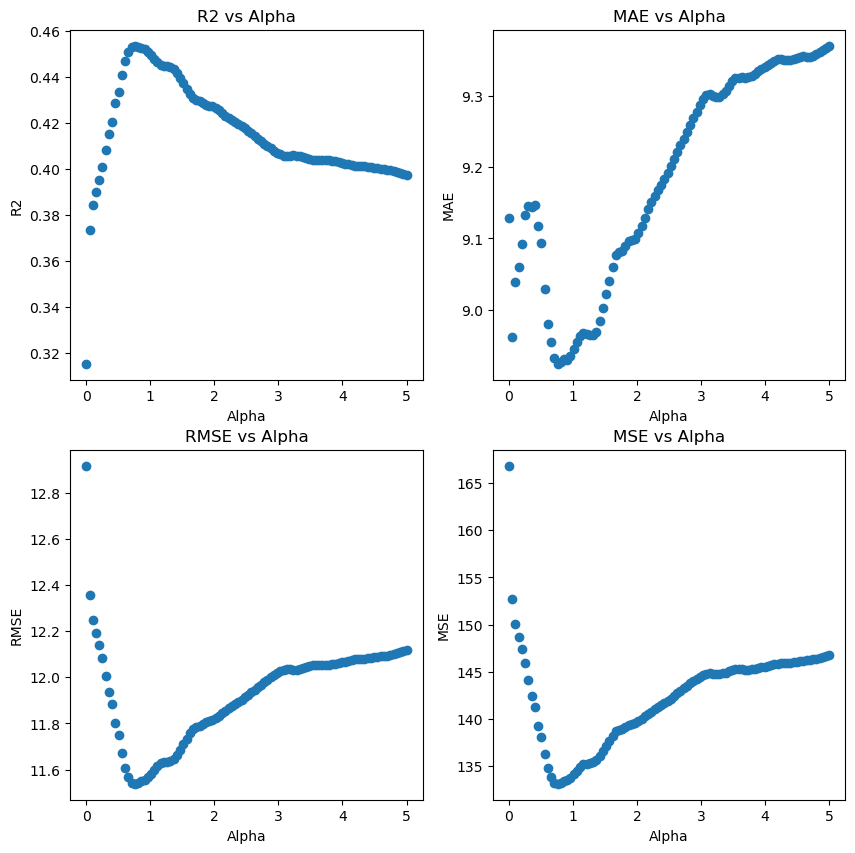

In [23]:
# want to plot 4 subplots for R2, MAE, RMSE, MSE vs alpha
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10, 10))
ax[0, 0].scatter(dfLasso['alpha'], dfLasso['R2'])           
ax[0, 0].set_xlabel('Alpha')
ax[0, 0].set_ylabel('R2')
ax[0, 0].set_title('R2 vs Alpha')

ax[0, 1].scatter(dfLasso['alpha'], dfLasso['MAE'])
ax[0, 1].set_xlabel('Alpha')
ax[0, 1].set_ylabel('MAE')
ax[0, 1].set_title('MAE vs Alpha')

ax[1, 0].scatter(dfLasso['alpha'], dfLasso['RMSE'])
ax[1, 0].set_xlabel('Alpha')
ax[1, 0].set_ylabel('RMSE')
ax[1, 0].set_title('RMSE vs Alpha')

ax[1, 1].scatter(dfLasso['alpha'], dfLasso['MSE'])
ax[1, 1].set_xlabel('Alpha')
ax[1, 1].set_ylabel('MSE')
ax[1, 1].set_title('MSE vs Alpha')

plt.show()


In [24]:
# now let's choose the model with the smallest MAE
optimal_alpha = dfLasso.loc[dfLasso['MAE'].idxmin(), 'alpha']
print(f'The optimal alpha is {optimal_alpha:.4f}')

The optimal alpha is 0.7577


In [43]:
# let's investigate with lasso_path the importance of the features
from sklearn.linear_model import lasso_path
alphasPath, coefsPath, *_ = lasso_path(features_df.loc[:, "f1_mass_PC1":],  data_df['Imax'], alphas= lAlpha)


c:\Users\KirilKiriyevsky\PythonMamba\envs\AIProgram\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.124e+02, tolerance: 5.600e+01
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\KirilKiriyevsky\PythonMamba\envs\AIProgram\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.694e+04, tolerance: 5.600e+01
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\KirilKiriyevsky\PythonMamba\envs\AIProgram\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the sc

In [45]:
alphasPath.shape

(301,)

In [46]:
coefsPath.shape

(54, 301)

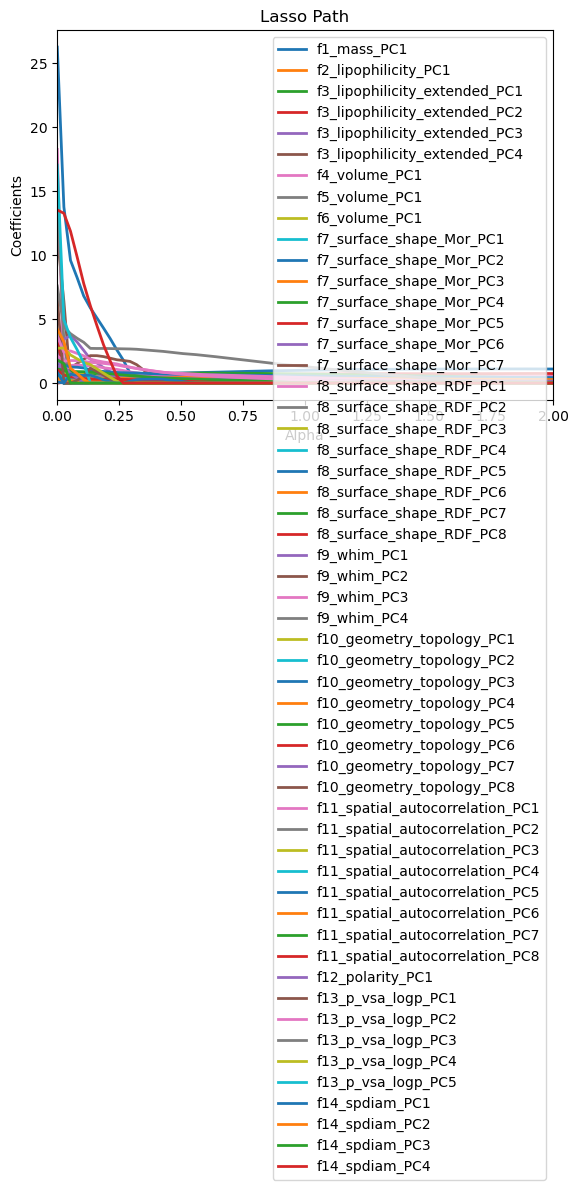

In [50]:
plt.plot(alphasPath, np.abs(coefsPath.T), lw = 2, label = features_df.loc[:, "f1_mass_PC1":].columns.to_list())
plt.xlim(0, 2)
plt.xlabel('Alpha')
plt.ylabel('Coefficients')
plt.title('Lasso Path')
plt.legend(loc = 'upper right')
plt.show()


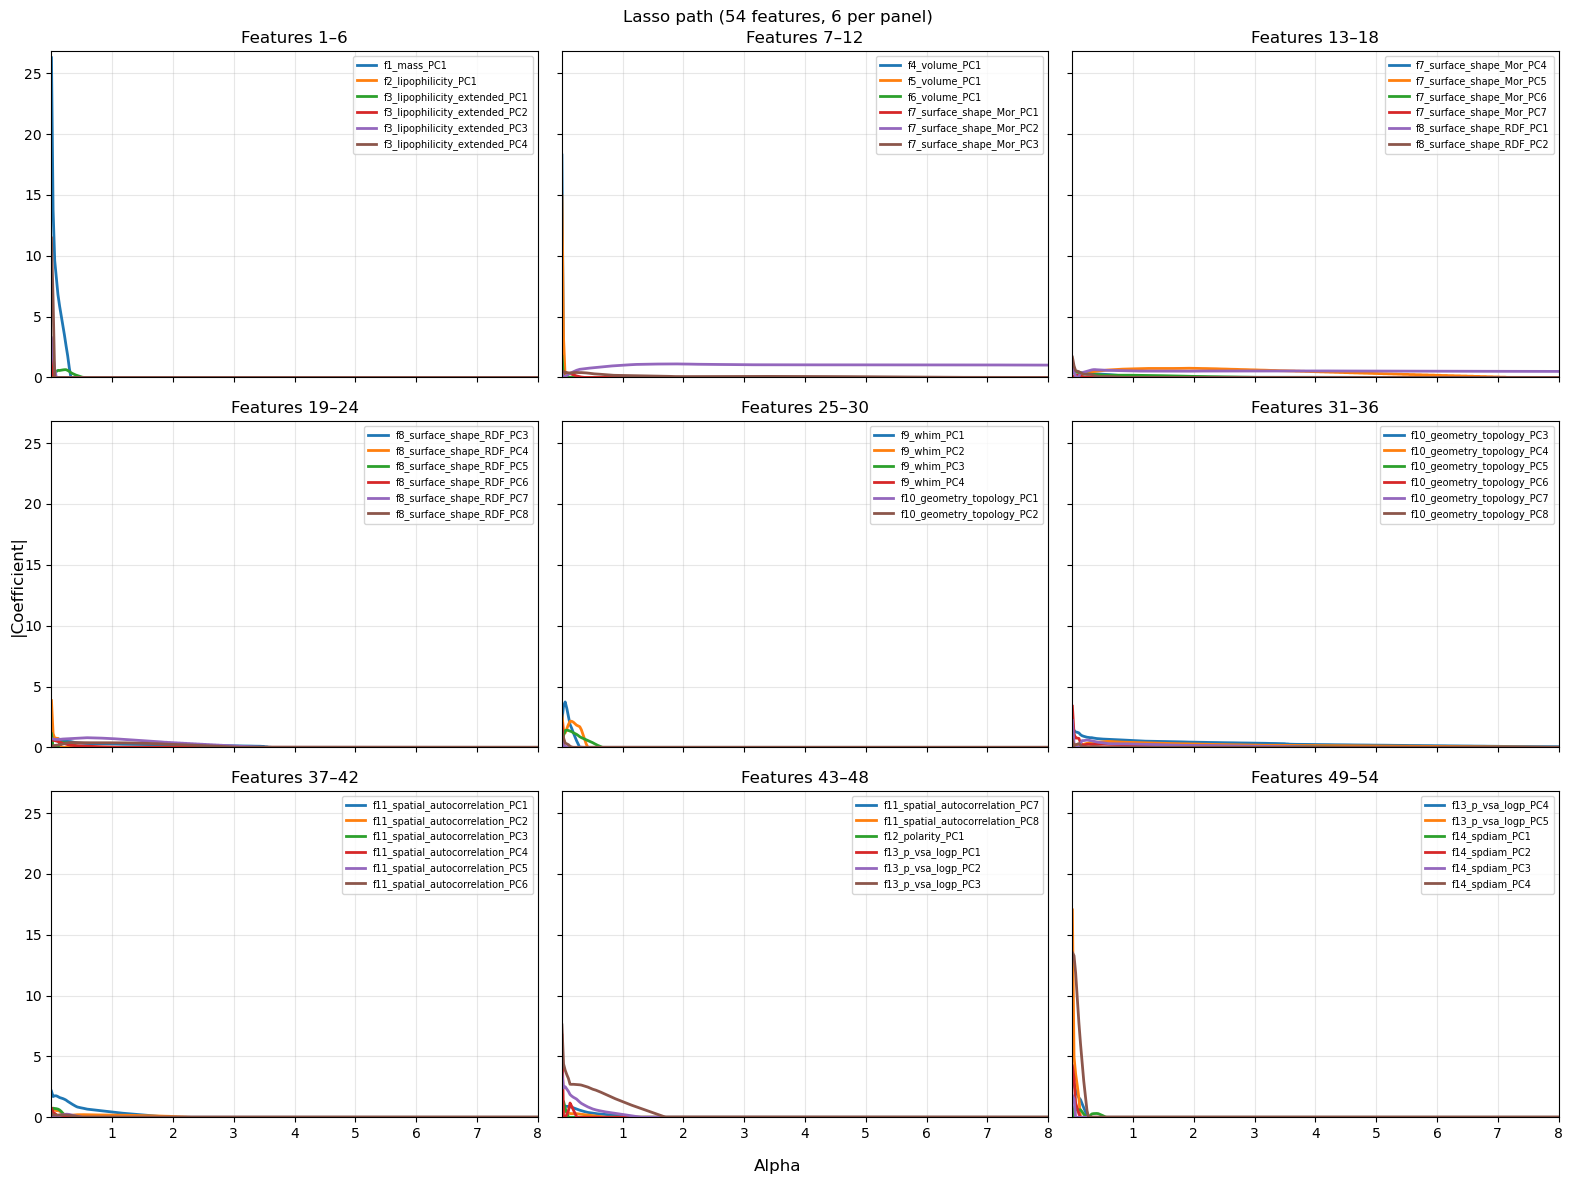

In [51]:
feature_names = features_df.loc[:, "f1_mass_PC1":].columns.to_list()
abs_coefs = np.abs(coefsPath)  # (54, n_alphas)

# Global limits so every subplot uses the same frame
xlim = (alphasPath.min(), alphasPath.max())
ylim = (0, abs_coefs.max() * 1.02)  # small top margin

fig, axes = plt.subplots(3, 3, figsize=(16, 12), sharex=True, sharey=True)

for k, ax in enumerate(axes.flat):
    i0, i1 = k * 6, k * 6 + 6
    for i in range(i0, i1):
        ax.plot(alphasPath, abs_coefs[i], lw=2, label=feature_names[i])
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_title(f'Features {i0 + 1}–{i1}')
    ax.legend(loc='upper right', fontsize=7)
    ax.grid(True, alpha=0.3)

fig.supxlabel('Alpha')
fig.supylabel('|Coefficient|')
fig.suptitle('Lasso path (54 features, 6 per panel)')
plt.tight_layout()
plt.show()

In [52]:
feature_names = features_df.loc[:, "f1_mass_PC1":].columns

# Lasso (sparse — zeros = "not selected")
coef_lasso = pd.Series(oLasso.coef_, index=feature_names)
top10_lasso = coef_lasso.abs().sort_values(ascending=False).head(10)

# Optional: sign + magnitude
top10_lasso_signed = coef_lasso.reindex(top10_lasso.index)

print(top10_lasso)
print(top10_lasso_signed)  # positive → higher PC → higher Imax, etc.

f13_p_vsa_logp_PC3                 1.801187
f7_surface_shape_Mor_PC2           0.913215
f8_surface_shape_RDF_PC7           0.766778
f7_surface_shape_Mor_PC5           0.662235
f10_geometry_topology_PC3          0.618447
f11_spatial_autocorrelation_PC1    0.569843
f8_surface_shape_RDF_PC1           0.559022
f10_geometry_topology_PC4          0.446792
f13_p_vsa_logp_PC2                 0.411271
f8_surface_shape_RDF_PC8           0.375993
dtype: float64
f13_p_vsa_logp_PC3                -1.801187
f7_surface_shape_Mor_PC2          -0.913215
f8_surface_shape_RDF_PC7           0.766778
f7_surface_shape_Mor_PC5           0.662235
f10_geometry_topology_PC3         -0.618447
f11_spatial_autocorrelation_PC1    0.569843
f8_surface_shape_RDF_PC1          -0.559022
f10_geometry_topology_PC4         -0.446792
f13_p_vsa_logp_PC2                 0.411271
f8_surface_shape_RDF_PC8          -0.375993
dtype: float64


In [25]:
# now let's train the model with the optimal alpha on whole dataset
oLasso = Lasso(alpha=optimal_alpha, max_iter=500_000)
oLasso.fit(mX, vY)
vY_pred = oLasso.predict(mX)

# calculate the R2 score
r2 = r2_score(vY, vY_pred)
print(f'The R2 score is {r2:.2f}')
# calculate the MAE
mae = mean_absolute_error(vY, vY_pred)
print(f'The MAE is {mae:.2f}')
# calculate the RMSE
rmse = np.sqrt(mean_squared_error(vY, vY_pred))
print(f'The RMSE is {rmse:.2f}')

# calculate the MSE
mse = mean_squared_error(vY, vY_pred)
print(f'The MSE is {mse:.2f}')



The R2 score is 0.53
The MAE is 8.27
The RMSE is 10.69
The MSE is 114.33


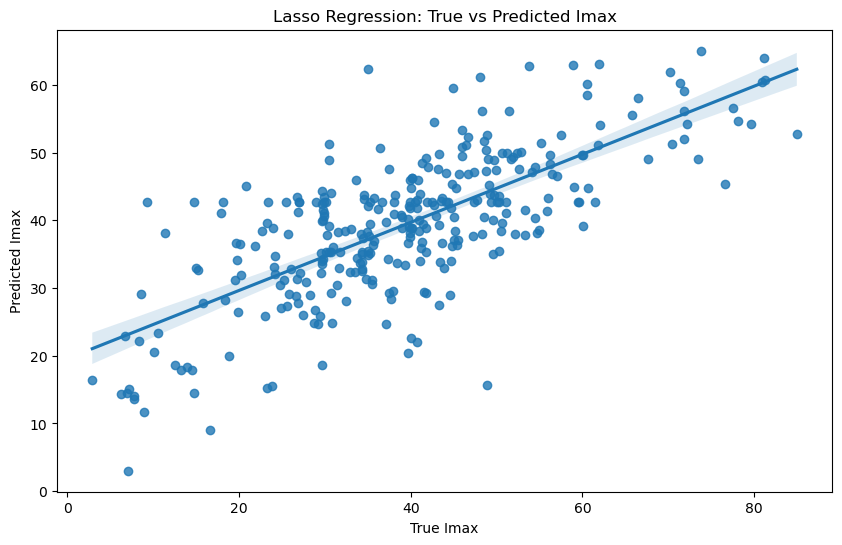

In [26]:
# now let's plot the predicted vs true values
fig, ax = plt.subplots(figsize=(10, 6))
sns.regplot(x=vY, y=vY_pred, ax=ax)
ax.set_xlabel('True Imax')
ax.set_ylabel('Predicted Imax')
ax.set_title('Lasso Regression: True vs Predicted Imax')
plt.show()

In [33]:
# now i want to do the same with Ridge regression

lAlpha = np.linspace(0.001, 8, 301)
kf = KFold(n_splits=len(vY), shuffle=True, random_state=42) # split for all samples


dfRidge = pd.DataFrame(columns=['alpha', 'R2', 'MAE', 'RMSE', 'MSE'], dtype=float)
dfRidge['alpha'] = lAlpha
dfRidge['R2'] = [0.0] * len(lAlpha)
dfRidge['MAE'] = [0.0] * len(lAlpha)
dfRidge['RMSE'] = [0.0] * len(lAlpha)
dfRidge['MSE'] = [0.0] * len(lAlpha)

for i, alpha in enumerate(lAlpha):
    print(f"Training Ridge with alpha = {alpha} model {i+1} of {len(lAlpha)}")
    oRidge = Ridge(alpha=alpha, max_iter=500_000)
    vY_pred = cross_val_predict(oRidge, mX, vY, cv=kf)
    dfRidge.loc[i, 'R2'] = r2_score(vY, vY_pred)
    dfRidge.loc[i, 'MAE'] = mean_absolute_error(vY, vY_pred)
    dfRidge.loc[i, 'RMSE'] = np.sqrt(mean_squared_error(vY, vY_pred))
    dfRidge.loc[i, 'MSE'] = mean_squared_error(vY, vY_pred)


Training Ridge with alpha = 0.001 model 1 of 301
Training Ridge with alpha = 0.02766333333333333 model 2 of 301
Training Ridge with alpha = 0.05432666666666666 model 3 of 301
Training Ridge with alpha = 0.08098999999999999 model 4 of 301
Training Ridge with alpha = 0.10765333333333332 model 5 of 301
Training Ridge with alpha = 0.13431666666666664 model 6 of 301
Training Ridge with alpha = 0.16097999999999998 model 7 of 301
Training Ridge with alpha = 0.18764333333333333 model 8 of 301
Training Ridge with alpha = 0.21430666666666665 model 9 of 301
Training Ridge with alpha = 0.24096999999999996 model 10 of 301
Training Ridge with alpha = 0.2676333333333333 model 11 of 301
Training Ridge with alpha = 0.29429666666666665 model 12 of 301
Training Ridge with alpha = 0.32095999999999997 model 13 of 301
Training Ridge with alpha = 0.3476233333333333 model 14 of 301
Training Ridge with alpha = 0.37428666666666666 model 15 of 301
Training Ridge with alpha = 0.40095 model 16 of 301
Training Ridg

In [34]:
dfRidge.head()

,alpha,R2,MAE,RMSE,MSE
0,0.001000,0.223962,9.448696,13.749701,189.054278
1,0.027663,0.268265,9.345083,13.351456,178.261372
2,0.054327,0.287024,9.283500,13.179208,173.691526
3,0.080990,0.297873,9.244285,13.078546,171.048362
4,0.107653,0.305194,9.214281,13.010186,169.264946


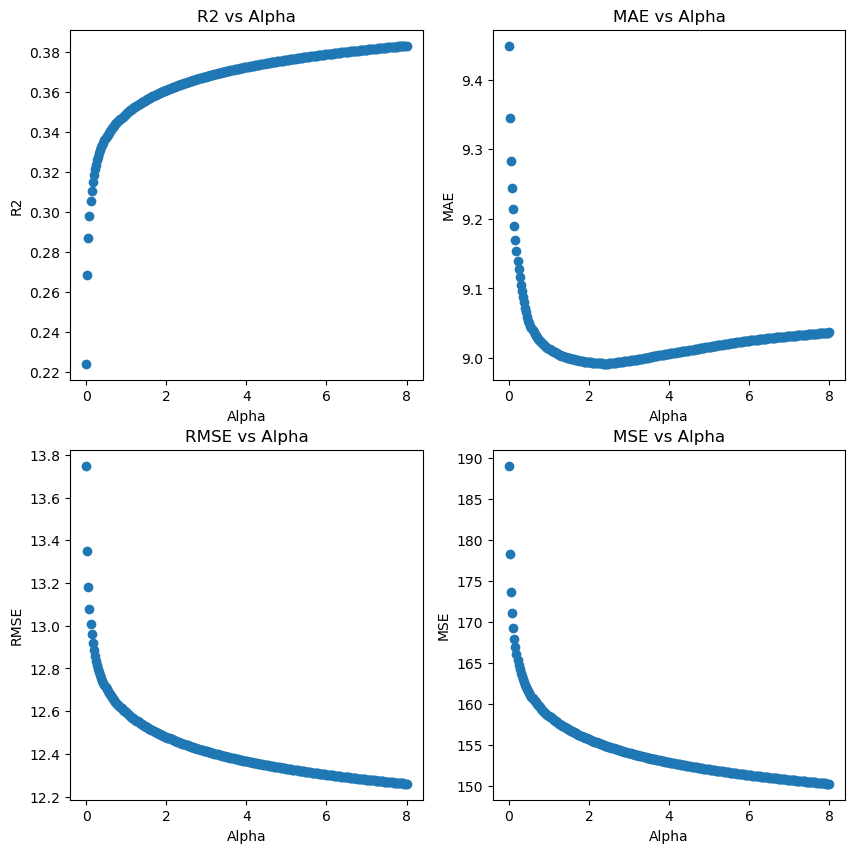

In [35]:
# visualization of the Ridge regression
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10, 10))
ax[0, 0].scatter(dfRidge['alpha'], dfRidge['R2'])
ax[0, 0].set_xlabel('Alpha')
ax[0, 0].set_ylabel('R2')
ax[0, 0].set_title('R2 vs Alpha')

ax[0, 1].scatter(dfRidge['alpha'], dfRidge['MAE'])
ax[0, 1].set_xlabel('Alpha')
ax[0, 1].set_ylabel('MAE')
ax[0, 1].set_title('MAE vs Alpha')

ax[1, 0].scatter(dfRidge['alpha'], dfRidge['RMSE'])
ax[1, 0].set_xlabel('Alpha')
ax[1, 0].set_ylabel('RMSE')
ax[1, 0].set_title('RMSE vs Alpha') 

ax[1, 1].scatter(dfRidge['alpha'], dfRidge['MSE'])
ax[1, 1].set_xlabel('Alpha')
ax[1, 1].set_ylabel('MSE')
ax[1, 1].set_title('MSE vs Alpha')

plt.show()






The optimal alpha is 2.4540
The R2 score is 0.61
The MAE is 7.44
The RMSE is 9.69


Text(0, 0.5, 'Predicted Imax')

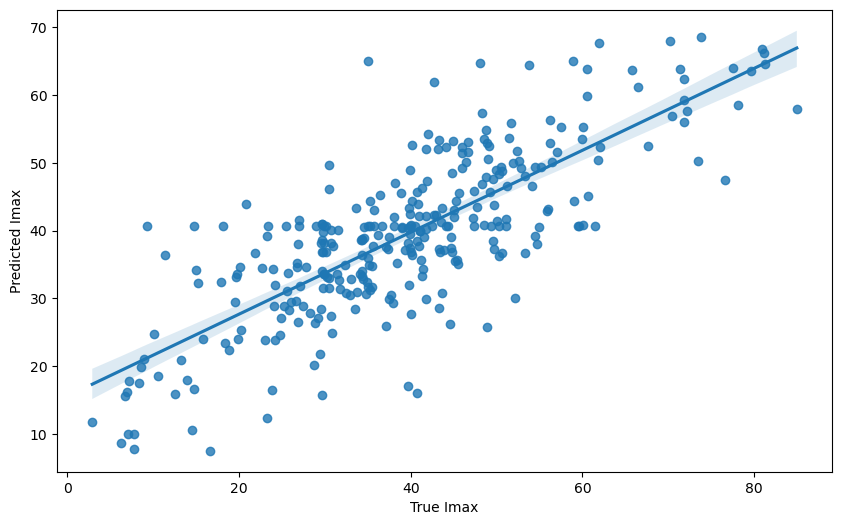

In [36]:
# finding the best alpha for Ridge regression
optimal_alpha = dfRidge.loc[dfRidge['MAE'].idxmin(), 'alpha']
print(f'The optimal alpha is {optimal_alpha:.4f}')
# now let's train the model with the optimal alpha on whole dataset
oRidge = Ridge(alpha=optimal_alpha, max_iter=500_000)
oRidge.fit(mX, vY)
vY_pred = oRidge.predict(mX)

# calculate the R2 score
r2 = r2_score(vY, vY_pred)
print(f'The R2 score is {r2:.2f}')
# calculate the MAE
mae = mean_absolute_error(vY, vY_pred)
print(f'The MAE is {mae:.2f}')
# calculate the RMSE
rmse = np.sqrt(mean_squared_error(vY, vY_pred))
print(f'The RMSE is {rmse:.2f}')

# calculate the MSE
mse = mean_squared_error(vY, vY_pred)
# now let's plot the predicted vs true values
fig, ax = plt.subplots(figsize=(10, 6))
sns.regplot(x=vY, y=vY_pred, ax=ax)
ax.set_xlabel('True Imax')
ax.set_ylabel('Predicted Imax')


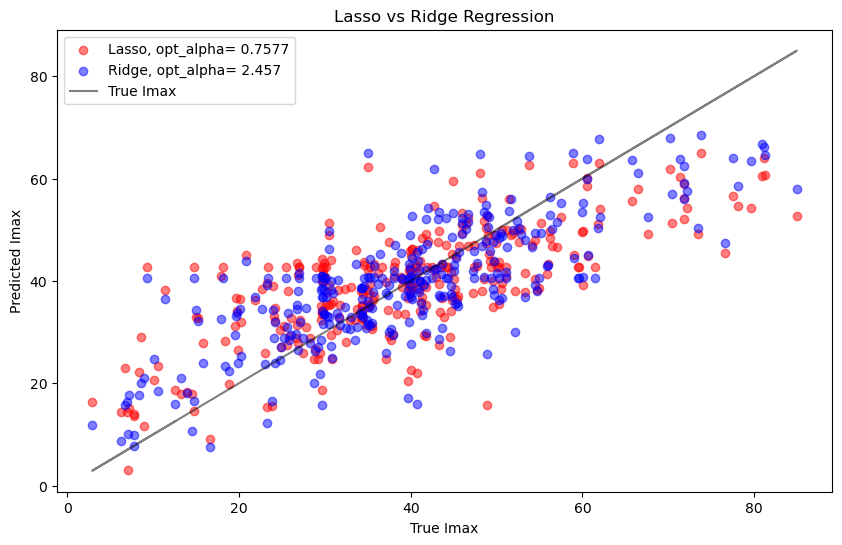

In [40]:
# now i want to plot scatter plots one for optimal alpha for lasso and one for optimal alpha for ridge

vY_pred_lasso = oLasso.predict(mX)
vY_pred_ridge = oRidge.predict(mX)

fig, ax = plt.subplots(figsize=(10, 6))
plt.scatter(vY, vY_pred_lasso, label=f'Lasso, opt_alpha= 0.7577', color='red',alpha=0.5)
plt.scatter(vY, vY_pred_ridge, label='Ridge, opt_alpha= 2.457', color='blue',alpha=0.5)
plt.plot(vY, vY, label='True Imax', color='black',alpha=0.5)
plt.xlabel('True Imax')
plt.ylabel('Predicted Imax')
plt.title('Lasso vs Ridge Regression')
plt.legend()
plt.show()


In [ ]:
#Coefficient importance with Ridge
feature_names = features_df.loc[:, "f1_mass_PC1":].columns

# Ridge coeficients
coef_ridge = pd.Series(oRidge.coef_, index=feature_names)
top10_ridge = coef_ridge.abs().sort_values(ascending=False).head(10)

# Optional: sign + magnitude
top10_ridge_signed = coef_ridge.reindex(top10_ridge.index)

print(top10_ridge)
print(top10_ridge_signed)  # positive → higher PC → higher Imax, etc.

f14_spdiam_PC4                   11.218676
f1_mass_PC1                       7.858843
f13_p_vsa_logp_PC3                4.237427
f13_p_vsa_logp_PC5                3.929406
f3_lipophilicity_extended_PC4     3.651141
f9_whim_PC1                       3.214441
f8_surface_shape_RDF_PC4          2.853095
f3_lipophilicity_extended_PC3     2.731077
f14_spdiam_PC2                    2.672176
f13_p_vsa_logp_PC2                2.502486
dtype: float64
f14_spdiam_PC4                   11.218676
f1_mass_PC1                      -7.858843
f13_p_vsa_logp_PC3               -4.237427
f13_p_vsa_logp_PC5               -3.929406
f3_lipophilicity_extended_PC4    -3.651141
f9_whim_PC1                       3.214441
f8_surface_shape_RDF_PC4          2.853095
f3_lipophilicity_extended_PC3     2.731077
f14_spdiam_PC2                    2.672176
f13_p_vsa_logp_PC2                2.502486
dtype: float64
